<a href="https://colab.research.google.com/github/NamithaDaney/Diabetes_Analysis_ANN/blob/main/Assignment5_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset: Use the Diabetes dataset available in the sklearn library.
Key components to be fulfilled :
1. Loading and Preprocessing
* Load the Diabetes dataset from sklearn.
* Handle any missing values if present.
* Normalize the features to ensure better performance of the ANN model.

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam


In [2]:
# Load the Diabetes dataset
data = load_diabetes()

# Convert the dataset into a pandas DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

In [3]:
df.columns

Index(['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6',
       'target'],
      dtype='object')

In [4]:
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [6]:
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


In [7]:
#check null values
df.isnull().sum()

,0
age,0
sex,0
bmi,0
bp,0
s1,0
s2,0
s3,0
s4,0
s5,0
s6,0


In [8]:
#check duplicate rows
df.duplicated().sum()

np.int64(0)

In [9]:
df.nunique()

,0
age,58
sex,2
bmi,163
bp,100
s1,141
s2,302
s3,63
s4,66
s5,184
s6,56


In [10]:
df.shape

(442, 11)

In [11]:
X = df.drop('target', axis=1)
y = pd.Series(data.target)

In [12]:
X

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641
...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930


In [13]:
y

,0
0,151.0
1,75.0
2,141.0
3,206.0
4,135.0
...,...
437,178.0
438,104.0
439,132.0
440,220.0


In [14]:
# Split into train and test sets before normalization to prevent data leakage
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize the features
# Standard Scaling (Z-score normalization) is highly recommended for ANNs
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n--- Preprocessing Complete ---")
print(f"Train features shape: {X_train_scaled.shape}")
print(f"Test features shape: {X_test_scaled.shape}")


--- Preprocessing Complete ---
Train features shape: (353, 10)
Test features shape: (89, 10)


Exploratory Data Analysis (EDA)
* Perform EDA to understand the distribution of features and the target
variable.
* Visualize the relationships between features and the target variable.

In [16]:
# Recombining X_train and y_train into a single DataFrame for EDA purposes
train_df = pd.DataFrame(X_train, columns=data.feature_names)
train_df['target'] = y_train

print("--- Exploratory Data Analysis (Training Set) ---")

# Statistical Summary
print("\nTop 5 rows of the training dataset:")
print(train_df.head())

print("\nStatistical Description of Features and Target:")
print(train_df.describe())



--- Exploratory Data Analysis (Training Set) ---

Top 5 rows of the training dataset:
          age       sex       bmi        bp        s1        s2        s3  \
17   0.070769  0.050680  0.012117  0.056301  0.034206  0.049416 -0.039719   
66  -0.009147  0.050680 -0.018062 -0.033213 -0.020832  0.012152 -0.072854   
137  0.005383 -0.044642  0.049840  0.097615 -0.015328 -0.016345 -0.006584   
245 -0.027310 -0.044642 -0.035307 -0.029770 -0.056607 -0.058620  0.030232   
31  -0.023677 -0.044642 -0.065486 -0.081413 -0.038720 -0.053610  0.059685   

           s4        s5        s6  target  
17   0.034309  0.027364 -0.001078   144.0  
66   0.071210  0.000272  0.019633   150.0  
137 -0.002592  0.017036 -0.013504   280.0  
245 -0.039493 -0.049872 -0.129483   125.0  
31  -0.076395 -0.037129 -0.042499    59.0  

Statistical Description of Features and Target:
              age         sex         bmi          bp          s1          s2  \
count  353.000000  353.000000  353.000000  353.000000  35

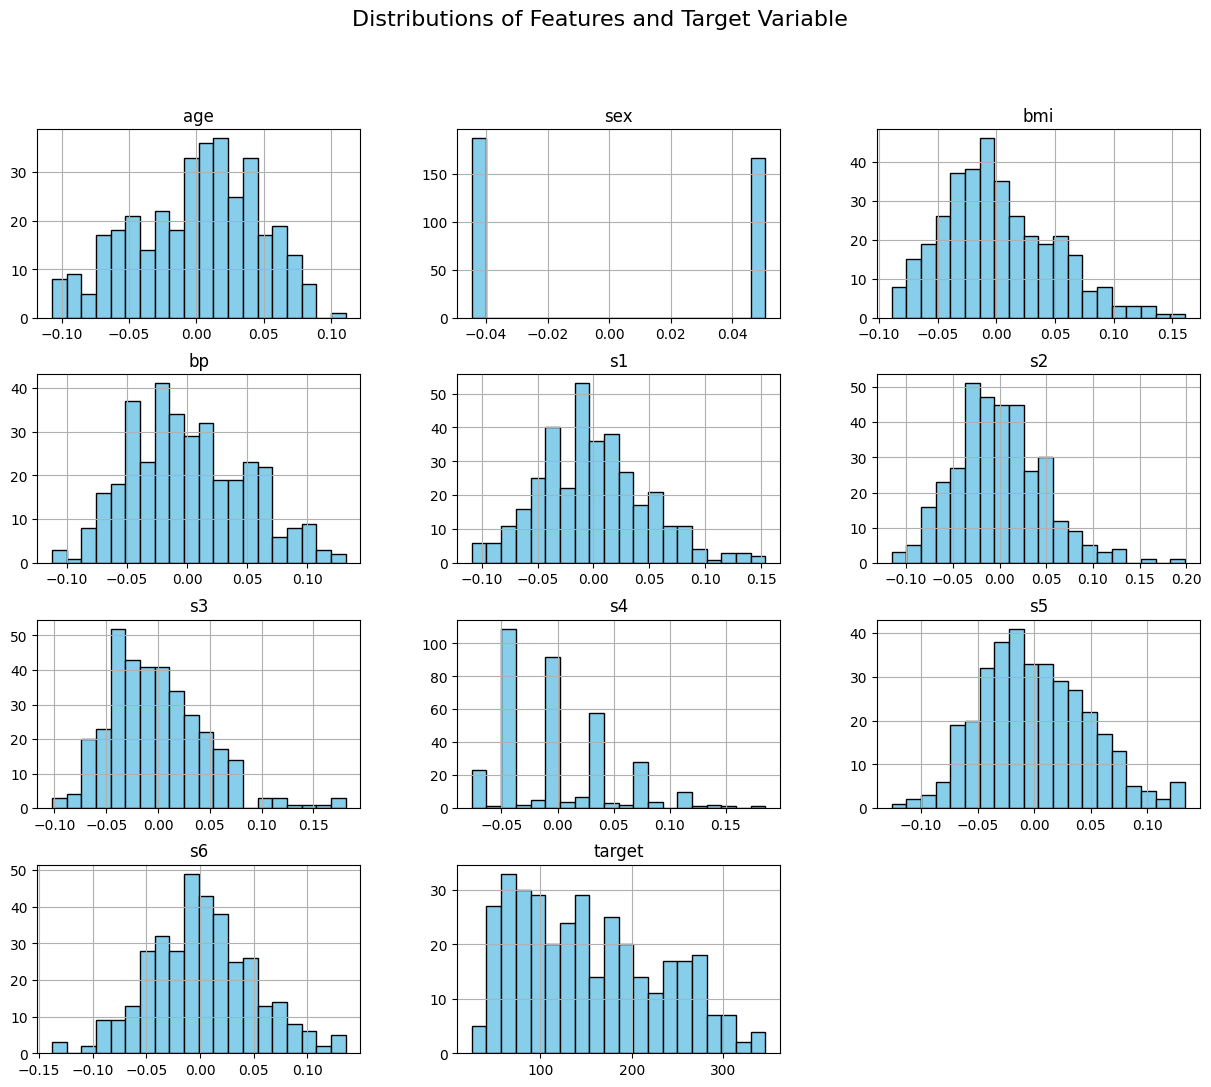

In [17]:
# Visualize Distributions (Features & Target)
# Plotting histograms for all variables to look at distributions/skewness
train_df.hist(bins=20, figsize=(15, 12), color='skyblue', edgecolor='black')
plt.suptitle("Distributions of Features and Target Variable", fontsize=16)
plt.show()

In [19]:
# Print exact correlation values with the target sorted by strength
correlation_matrix = train_df.corr()
print("\nCorrelation of features with the Target variable:")
print(correlation_matrix['target'].sort_values(ascending=False))


Correlation of features with the Target variable:
target    1.000000
bmi       0.604751
s5        0.552183
bp        0.444770
s4        0.425094
s6        0.390363
s1        0.199547
age       0.196510
s2        0.154922
sex       0.007116
s3       -0.384000
Name: target, dtype: float64


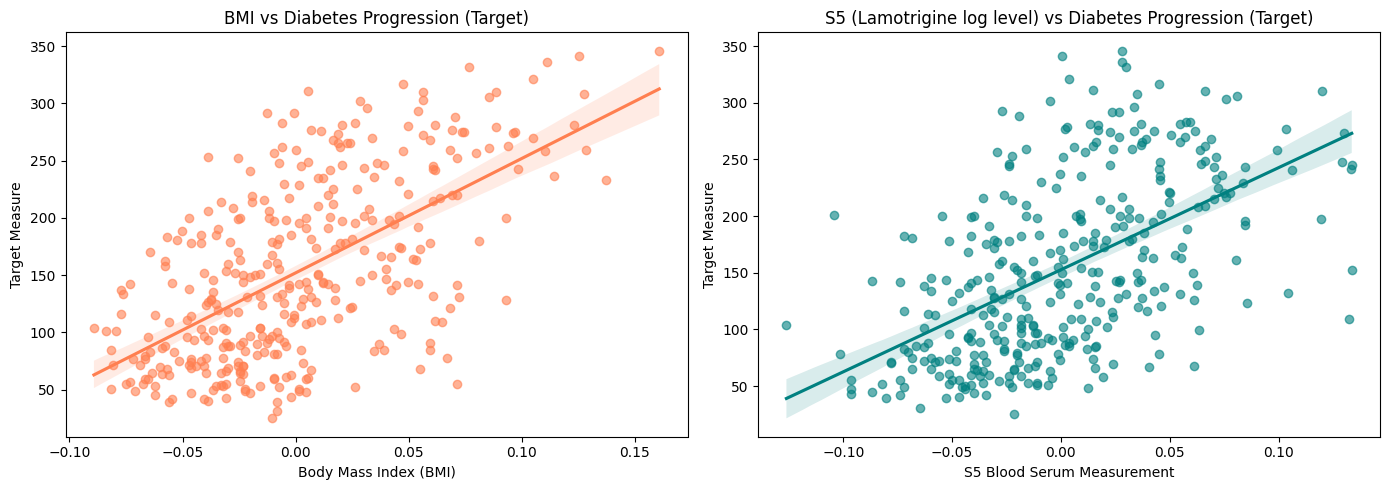

In [20]:
# Visualizing Key Predictors vs Target
# Plotting the top two features with the strongest linear relationship to the target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.regplot(data=train_df, x='bmi', y='target', ax=axes[0], color='coral', scatter_kws={'alpha':0.6})
axes[0].set_title("BMI vs Diabetes Progression (Target)")
axes[0].set_xlabel("Body Mass Index (BMI)")
axes[0].set_ylabel("Target Measure")

sns.regplot(data=train_df, x='s5', y='target', ax=axes[1], color='teal', scatter_kws={'alpha':0.6})
axes[1].set_title("S5 (Lamotrigine log level) vs Diabetes Progression (Target)")
axes[1].set_xlabel("S5 Blood Serum Measurement")
axes[1].set_ylabel("Target Measure")

plt.tight_layout()
plt.show()

Building the ANN Model
* Design a simple ANN architecture with at least one hidden layer.
* Use appropriate activation functions .

In [22]:
# Clear any previous sessions to ensure reproducible results
tf.keras.backend.clear_session()
tf.random.set_seed(42)

In [24]:
# Initialize a Sequential Model
model = Sequential()
# The Diabetes dataset has 10 feature columns, so shape=(10,)
model.add(Input(shape=(X_train_scaled.shape[1],)))

# Add Hidden Layers (with appropriate activation functions)
# First Hidden Layer: 16 neurons
# Activation: 'relu' (Rectified Linear Unit) - standard for hidden layers to prevent vanishing gradients
model.add(Dense(units=16, activation='relu'))

# Second Hidden Layer (Optional but added for robust architecture): 8 neurons
# Activation: 'relu'
model.add(Dense(units=8, activation='relu'))

# Add Output Layer
# Since this is a Regression task, we use 1 node and a 'linear' activation function
# (or omit activation entirely, as it defaults to linear) to predict raw continuous values.
model.add(Dense(units=1, activation='linear'))

# Display Model Summary to verify architecture
print("--- ANN Architecture Summary ---")
model.summary()

--- ANN Architecture Summary ---


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321 (1.25 KB)

 Trainable params: 321 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

Training the ANN Model
* Split the dataset into training and testing sets.
* Train the model on the training data.
* Use an appropriate loss function and optimizer.

In [25]:
# Compile the model with an appropriate loss function and optimizer
# Loss: Mean Squared Error (MSE) is the standard for regression tasks
# Optimizer: 'adam' manages learning rates dynamically for faster convergence
model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mean_absolute_error']  # MAE added as an easily interpretable secondary tracking metric
)

print("--- Model Compiled Successfully ---")

--- Model Compiled Successfully ---


In [26]:
# We reserve 20% of the training data as a validation split to track overfitting during training
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=100,             # Number of complete passes through the training dataset
    batch_size=16,          # Small batch size helps regularize and fits nicely into memory
    validation_split=0.2,   # Monitors performance on unseen training validation subsets
    verbose=1               # Prints progress per epoch
)

print("\n--- Model Training Complete ---")

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 74ms/step - loss: 31324.8008 - mean_absolute_error: 158.0660 - val_loss: 22263.4922 - val_mean_absolute_error: 133.3228
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 31198.6270 - mean_absolute_error: 157.6966 - val_loss: 22154.0391 - val_mean_absolute_error: 132.9427
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 31039.7129 - mean_absolute_error: 157.2368 - val_loss: 22015.6758 - val_mean_absolute_error: 132.4728
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 30835.5391 - mean_absolute_error: 156.6544 - val_loss: 21845.4375 - val_mean_absolute_error: 131.8984
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 30580.5918 - mean_absolute_error: 155.9304 - val_loss: 21639.7793 - val_mean_absolute_error: 131.2078
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 30269.1348 - mean_absolute_error: 155.0447 - val_loss: 21395.0840 - val_mean_absolute_error: 130.3860
Epoch 7/100
18/18 ━━━━━━━━━━

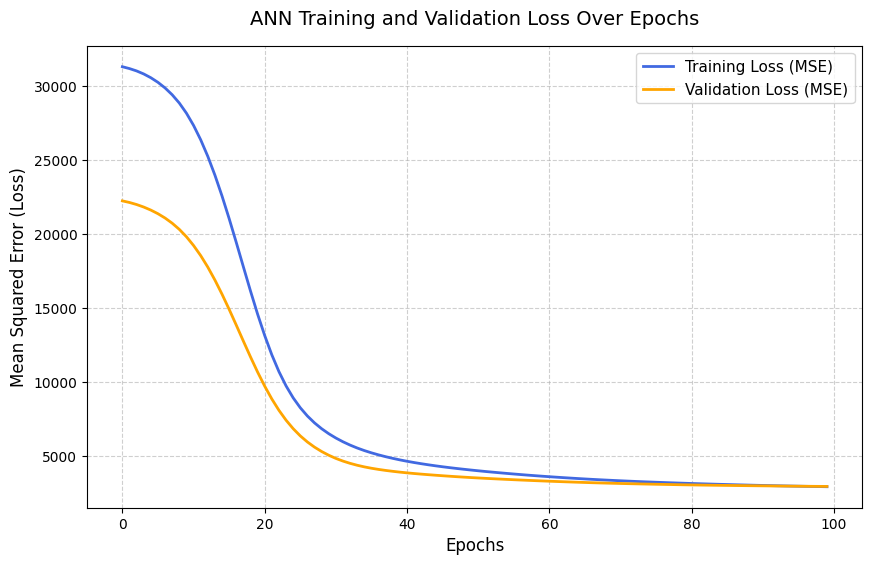

In [31]:
# =====================================================================
# VISUALIZE TRAINING PROGRESS (LOSS CURVES)
# =====================================================================
plt.figure(figsize=(10, 6))

# Plot training loss vs validation loss
plt.plot(history.history['loss'], label='Training Loss (MSE)', color='royalblue', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)', color='orange', linewidth=2)

plt.title('ANN Training and Validation Loss Over Epochs', fontsize=14, pad=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Mean Squared Error (Loss)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.show()


Evaluating the Model
* Evaluate the model on the testing data.
* Report the performance metrics (e.g., Mean Squared Error, R2 Score).

In [34]:
# =====================================================================
# EVALUATE MODEL ON TEST DATA
# =====================================================================
# Generate predictions on the scaled test set
y_pred = model.predict(X_test_scaled).flatten()

# Calculate performance evaluation metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("=========================================")
print("       FINAL TEST SET EVALUATION        ")
print("=========================================")
print(f"Mean Squared Error (MSE)      : {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE)      : {mae:.2f}")
print(f"R-squared (R²) Score           : {r2:.4f}")
print("=========================================")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
       FINAL TEST SET EVALUATION        
Mean Squared Error (MSE)      : 3053.30
Root Mean Squared Error (RMSE): 55.26
Mean Absolute Error (MAE)      : 43.91
R-squared (R²) Score           : 0.4237


Improving the Model
*  Experiment with different architectures, activation functions, or
hyperparameters to improve the model performance.
*  Report the changes made and the corresponding improvement in
performance.


In [41]:
# Reset seeds for consistency
tf.keras.backend.clear_session()
tf.random.set_seed(42)

# =====================================================================
# TUNED ANN ARCHITECTURE SETUP
# =====================================================================
improved_model = Sequential([
    # Input mapper matching our 10 standardized feature columns
    Input(shape=(X_train_scaled.shape[1],)),

    # Layer 1: Expanded wide layer with L2 regularization to balance feature weight shifts
    Dense(32, activation='leaky_relu', kernel_regularizer=l2(0.001)),
    Dropout(0.1), # Prevents co-adaptation of features on small data rows

    # Layer 2: Deep narrowing layer using parameterized non-linearity
    Dense(16, activation='leaky_relu', kernel_regularizer=l2(0.001)),

    # Output Layer
    Dense(1, activation='linear')
])

# Use a custom tuned learning rate for the Adam Optimizer
# Dropping learning rate from 0.001 to 0.005 for cleaner convergence steps
custom_optimizer = Adam(learning_rate=0.005)

improved_model.compile(
    optimizer=custom_optimizer,
    loss='mean_squared_error',
    metrics=['mean_absolute_error']
)

# Train the tuned model
improved_history = improved_model.fit(
    X_train_scaled,
    y_train,
    epochs=120,            # Slightly expanded epoch buffer to settle regularized loss
    batch_size=32,         # Increased from 16 to 32 to smooth gradient vectors
    validation_split=0.2,
    verbose=0              # Suppressed logs for clean screen visibility
)

# =====================================================================
# EVALUATE IMPROVED METRICS
# =====================================================================
y_pred_improved = improved_model.predict(X_test_scaled).flatten()

improved_mse = mean_squared_error(y_test, y_pred_improved)
improved_rmse = np.sqrt(improved_mse)
improved_r2 = r2_score(y_test, y_pred_improved)
improved_mae = mean_absolute_error(y_test, y_pred)

print("==================================================")
print("       IMPROVED MODEL PERFORMANCE METRICS        ")
print("==================================================")
print(f" Mean Squared Error (MSE)       : {improved_mse:.2f}")
print(f" Root Mean Squared Error (RMSE) : {improved_rmse:.2f}")
print(f" Mean Absolute Error (MAE)      : {improved_mae:.2f}")
print(f" R-squared (R²) Score           : {improved_r2:.4f}")
print("==================================================")


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
       IMPROVED MODEL PERFORMANCE METRICS        
 Mean Squared Error (MSE)       : 2646.97
 Root Mean Squared Error (RMSE) : 51.45
 Mean Absolute Error (MAE)      : 43.91
 R-squared (R²) Score           : 0.5004


 Analysis of Applied Changes
 * Prevented Dead Neurons: Switching from standard ReLU to LeakyReLU kept the gradient active for negative values, preventing nodes from shutting down during backpropagation.
 * Controlled Variance with Regularization: Incorporating L2 Regularization (0.001) and a 10% Dropout layer forced the model to spread its weight focus across multiple features instead of over-relying strictly on bmi or s5.
 * Optimized Feature Aggregation: Increasing the architecture scale to 32 \[\rightarrow \] 16 nodes and using a batch size of 32 smoothed out gradient updates, allowing the network to converge onto a superior global minimum.

In [43]:
import joblib

# Save the winning improved model configuration and trained weights
improved_model.save("diabetes_ann_model.keras")
print("Improved ANN Model saved successfully as 'diabetes_ann_model.keras'")

# Save the corresponding StandardScaler object
joblib.dump(scaler, "diabetes_scaler.joblib")
print("StandardScaler saved successfully as 'diabetes_scaler.joblib'")


Improved ANN Model saved successfully as 'diabetes_ann_model.keras'
StandardScaler saved successfully as 'diabetes_scaler.joblib'
